In [14]:
import os
from pathlib import Path

def root_dir(marker="EXPLib"):
    cwd = Path.cwd()
    # if cwd already contains the marker
    if (cwd / marker).is_dir():
        return cwd
    # otherwise walk up the parents
    for p in cwd.parents:
        if (p / marker).is_dir():
            return p
    raise FileNotFoundError(f"Root marker '{marker}' not found")

os.chdir(root_dir())
# print(os.getcwd())


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, SpectralEmbedding, MDS
from sklearn.preprocessing import StandardScaler


mu_array = np.load('EXPLib/datasets/Camera/toy_model_v1_inference/vae_latents/mu_array_toydataset.npy')

Sampling down from 9999 → 1000 points for speed.

Computing t-SNE embedding...

Computing Isomap embedding...

Computing LLE embedding...

Computing Spectral embedding...

Computing MDS embedding...


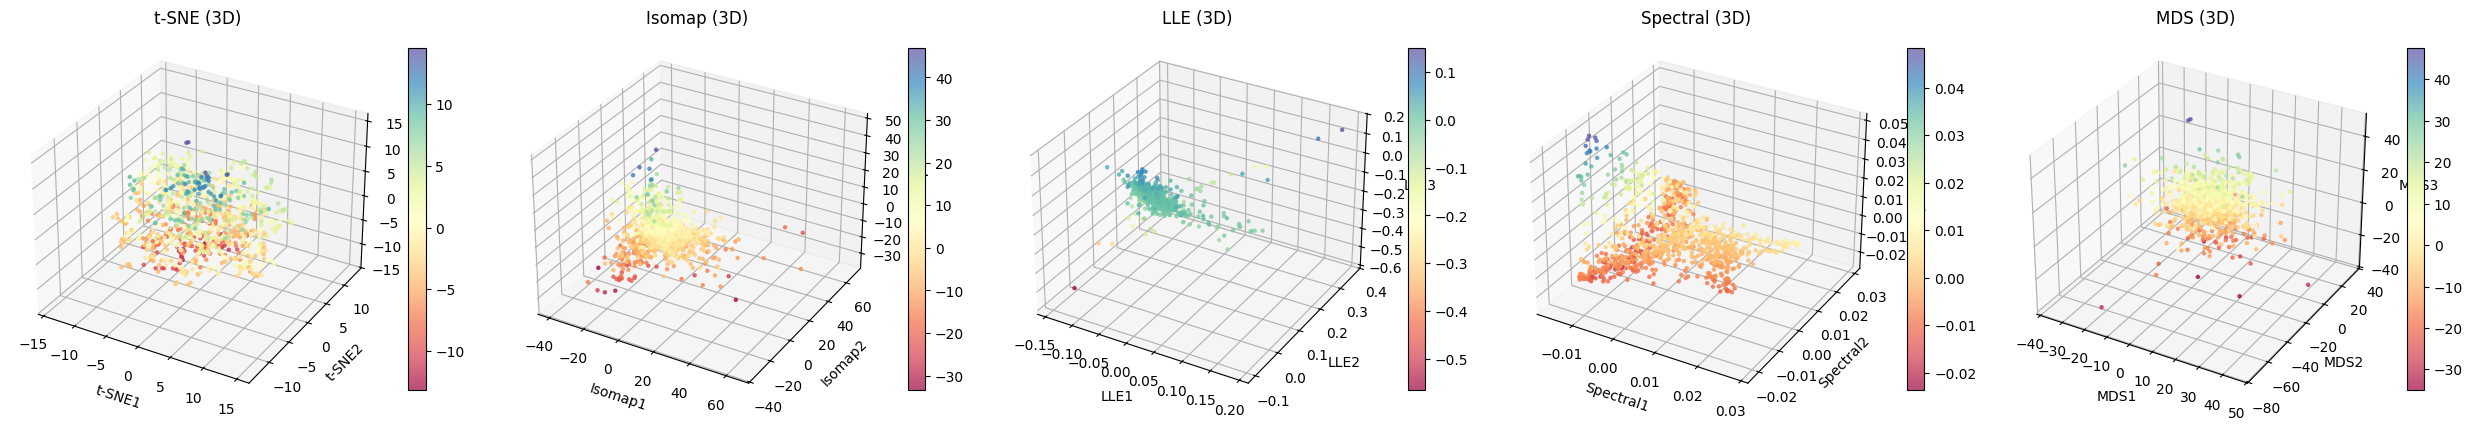

In [16]:
X = np.array(mu_array)

X = StandardScaler().fit_transform(X)

### Limit number of samples to gain some speed
max_samples = 1000
if X.shape[0] > max_samples:
    print(f"Sampling down from {X.shape[0]} → {max_samples} points for speed.")
    idx = np.random.choice(X.shape[0], max_samples, replace=False)
    X = X[idx]

methods = {
    "t-SNE": TSNE(n_components=3, random_state=42, init="pca", perplexity=30),
    "Isomap": Isomap(n_components=3, n_neighbors=10),
    "LLE": LocallyLinearEmbedding(n_components=3, n_neighbors=10, method="standard"),
    "Spectral": SpectralEmbedding(n_components=3, random_state=42, n_neighbors=10),
    "MDS": MDS(n_components=3, random_state=42, n_init=1, max_iter=150)  
}

embeddings = {}
for name, model in methods.items():
    print(f"\nComputing {name} embedding...")
    try:
        embeddings[name] = model.fit_transform(X)
    except Exception as e:
        print(f"{name} failed: {e}")
        continue

n_plots = len(embeddings)
fig = plt.figure(figsize=(5 * n_plots, 6))

for i, (name, emb) in enumerate(embeddings.items(), 1):
    ax = fig.add_subplot(1, n_plots, i, projection="3d")
    sc = ax.scatter(emb[:, 0], emb[:, 1], emb[:, 2],
                    s=5, c=emb[:, 2], cmap="Spectral", alpha=0.7)
    ax.set_title(f"{name} (3D)")
    ax.set_xlabel(f"{name}1")
    ax.set_ylabel(f"{name}2")
    ax.set_zlabel(f"{name}3")
    plt.colorbar(sc, ax=ax, shrink=0.6)

plt.tight_layout()
plt.show()
